# Active-Learning Optimization with a Surrogate

This notebook walks through `discopt.doe.optimize_round` — an
**active-learning** loop that finds the input minimizing or maximizing
a measured response, using as few experiments as possible.

The idea, going back at least to {cite:t}`Box1951` for response-surface
methods and {cite:t}`Jones1998` for Bayesian optimization with
Gaussian processes, is to never run a fixed design. Instead, after
every batch of experiments:

1. fit a probabilistic *surrogate* model to the responses you have
   so far;
2. use an *acquisition function* to score where the next experiment
   would be most useful — exploiting the surrogate's predicted
   optimum, while exploring where the surrogate is uncertain;
3. run the recommended batch, append the results, and repeat.

The key abstraction is that the optimizer only ever needs the
surrogate's predicted **mean and standard deviation** at candidate
points. Anything that can produce those two arrays — a GP with a
kernel of your choice {cite:p}`Rasmussen2006`, a Bayesian linear
model, an LPR local-prediction regressor, your own object — slots in.

## When to use this notebook's approach

* You want **the best input**, not the most precise model parameters.
  (For parameter estimation, use `optimal_experiment` instead.)
* Experiments are expensive — full factorials or response-surface
  designs are too wasteful.
* You can usually already screen out irrelevant factors with
  `factorial_2level_design` before optimizing.

## Plan of this notebook

1. A 1D toy problem with closed-form ground truth, to build intuition
   for the loop.
2. The same problem with a *user-supplied GP kernel* (Matern + white
   noise), to demonstrate the bring-your-own-model path.
3. A 2D example showing batch recommendation + the GP's posterior.
4. Practical guidance: choosing a surrogate, choosing an acquisition,
   stopping criteria, and known limitations.


In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import warnings
import numpy as np
import matplotlib.pyplot as plt
from openpyxl import load_workbook

from discopt.doe import (
    OptimizationCriterion,
    optimize_round,
)
from discopt.doe.workbook import InputSpec, Workbook

warnings.filterwarnings("ignore", message=".*ConvergenceWarning.*")
rng = np.random.default_rng(0)


## 1. A 1D problem with a true optimum

The simulated response is

$$y(x) = -(x - 2)^2 + 3 + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, 0.05^2)$$

so the true maximum is $y^\star = 3$ at $x^\star = 2$. The
optimizer does not know this — it only sees the responses we feed
it through the workbook.

We start the loop by seeding it with four random runs.

In [2]:
def truth_1d(x):
    return -(x - 2.0) ** 2 + 3.0 + 0.05 * np.random.default_rng().normal()

WORKBOOK = "/tmp/active_learning_1d.xlsx"
Workbook.create(
    WORKBOOK,
    template=None,
    template_args={},
    input_specs=[InputSpec("x", -5.0, 5.0)],
    criterion="custom",
    measurement_error=0.05,
    seed=0,
    response_name="y",
)
wb = Workbook.open(WORKBOOK)
init_x = np.array([-4.0, -1.0, 1.5, 4.0])
wb.append_runs(0, [{"x": float(x)} for x in init_x])
wb.save()

# Fill the responses we "measured"
book = load_workbook(WORKBOOK)
sh = book["runs"]
for i, x in enumerate(init_x, start=2):
    sh.cell(row=i, column=4, value=float(truth_1d(x)))
book.save(WORKBOOK)

list(Workbook.open(WORKBOOK).completed_runs())


[{'run_id': 1,
  'batch': 0,
  'x': -4,
  'y': -33.02803072022783,
  'measured_at': None},
 {'run_id': 2,
  'batch': 0,
  'x': -1,
  'y': -5.988287940936011,
  'measured_at': None},
 {'run_id': 3,
  'batch': 0,
  'x': 1.5,
  'y': 2.646758018093148,
  'measured_at': None},
 {'run_id': 4,
  'batch': 0,
  'x': 4,
  'y': -0.9620965067672387,
  'measured_at': None}]

### Running one round

A single call to `optimize_round` does the four steps in turn —
read completed runs → fit the surrogate → score candidates → append
the next batch.

In [3]:
def fill_responses(path, run_ids, designs, truth_fn):
    book = load_workbook(path)
    sh = book["runs"]
    by_id = {rid: d for rid, d in zip(run_ids, designs)}
    for row in sh.iter_rows(min_row=2):
        rid = row[0].value
        if rid in by_id:
            row[3].value = float(truth_fn(by_id[rid]["x"]))
    book.save(path)


result = optimize_round(
    workbook=WORKBOOK,
    criterion=OptimizationCriterion.MAXIMIZE,
    surrogate="gp",                        # string preset
    acquisition="expected_improvement",    # the standard BO choice
    batch_size=2,
    seed=0,
)
print("next batch:", result.next_designs)
print("incumbent so far:", result.incumbent_x, "->", round(result.incumbent_y, 3))
fill_responses(WORKBOOK, result.new_run_ids, result.next_designs, truth_1d)


next batch: [{'x': 2.4120481312274933}, {'x': 1.1990866344422102}]
incumbent so far: {'x': 1.5} -> 2.647


/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


### Iterating to convergence

We run six rounds of two experiments each and watch the incumbent
approach the truth.

In [4]:
history = []
for rnd in range(6):
    result = optimize_round(
        workbook=WORKBOOK,
        criterion=OptimizationCriterion.MAXIMIZE,
        surrogate="gp",
        acquisition="expected_improvement",
        batch_size=2,
        seed=rnd + 1,
    )
    fill_responses(WORKBOOK, result.new_run_ids, result.next_designs, truth_1d)
    completed = Workbook.open(WORKBOOK).completed_runs()
    ys = [float(r["y"]) for r in completed]
    best = max(range(len(ys)), key=lambda i: ys[i])
    history.append({
        "round": rnd,
        "n_runs": len(completed),
        "best_y": ys[best],
        "best_x": float(completed[best]["x"]),
    })

for h in history:
    print(h)
print()
print(f"truth max: y=3.0 at x=2.0")


/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Use

/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


{'round': 0, 'n_runs': 8, 'best_y': 3.125594830793453, 'best_x': 2.136436272412539}
{'round': 1, 'n_runs': 10, 'best_y': 3.125594830793453, 'best_x': 2.136436272412539}
{'round': 2, 'n_runs': 12, 'best_y': 3.125594830793453, 'best_x': 2.136436272412539}
{'round': 3, 'n_runs': 14, 'best_y': 3.125594830793453, 'best_x': 2.136436272412539}
{'round': 4, 'n_runs': 16, 'best_y': 3.125594830793453, 'best_x': 2.136436272412539}
{'round': 5, 'n_runs': 18, 'best_y': 3.125594830793453, 'best_x': 2.136436272412539}

truth max: y=3.0 at x=2.0


### Visualizing what the surrogate believes

After all rounds we refit the GP to every completed run and plot its
mean + 95% credible band, the truth, and the points the optimizer
chose to evaluate.

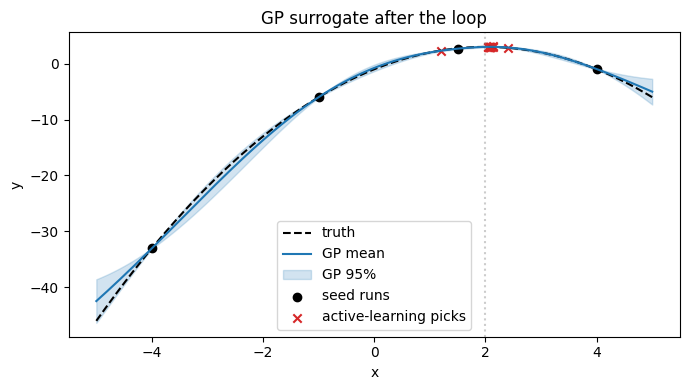

In [5]:
from discopt.doe.surrogate import coerce_surrogate

completed = Workbook.open(WORKBOOK).completed_runs()
X = np.array([[float(r["x"])] for r in completed])
y = np.array([float(r["y"]) for r in completed])

s = coerce_surrogate("gp")
s.fit(X, y)

xs = np.linspace(-5, 5, 400).reshape(-1, 1)
mu, sd = s.predict(xs)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(xs.ravel(), -(xs.ravel() - 2.0) ** 2 + 3.0, "k--", label="truth")
ax.plot(xs.ravel(), mu, "C0-", label="GP mean")
ax.fill_between(xs.ravel(), mu - 1.96 * sd, mu + 1.96 * sd,
                color="C0", alpha=0.2, label="GP 95%")
ax.scatter(X[: len(init_x), 0], y[: len(init_x)], color="k",
           marker="o", label="seed runs")
ax.scatter(X[len(init_x):, 0], y[len(init_x):], color="C3",
           marker="x", label="active-learning picks")
ax.axvline(2.0, color="grey", linestyle=":", alpha=0.4)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("GP surrogate after the loop")
ax.legend(loc="lower center")
plt.tight_layout(); plt.show()


The picks cluster near $x = 2$ — exactly where they should — but
notice a few exploration picks well away from the incumbent. That is
the EI acquisition doing its job: it discounts the predicted-mean
gain by the surrogate's uncertainty, so points where the GP is
nervous still get sampled.

## 2. Bring-your-own GP kernel

The string preset `"gp"` chooses Matern(5/2) + white noise. If you
want a different kernel — or any other UQ-providing scikit-learn
estimator — pass the estimator directly. The adapter detects
`predict(X, return_std=True)` and wires it up automatically.

In [6]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# Reset workbook to compare apples to apples
WORKBOOK2 = "/tmp/active_learning_1d_rbf.xlsx"
Workbook.create(
    WORKBOOK2, template=None, template_args={},
    input_specs=[InputSpec("x", -5.0, 5.0)],
    criterion="custom", measurement_error=0.05, seed=0, response_name="y",
)
wb2 = Workbook.open(WORKBOOK2)
wb2.append_runs(0, [{"x": float(x)} for x in init_x])
wb2.save()
book = load_workbook(WORKBOOK2)
sh = book["runs"]
for i, x in enumerate(init_x, start=2):
    sh.cell(row=i, column=4, value=float(truth_1d(x)))
book.save(WORKBOOK2)

my_gp = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0) * RBF(length_scale=1.0)
           + WhiteKernel(noise_level=0.01),
    normalize_y=True,
    n_restarts_optimizer=4,
)

for rnd in range(4):
    result = optimize_round(
        workbook=WORKBOOK2,
        criterion=OptimizationCriterion.MAXIMIZE,
        surrogate=my_gp,                  # <-- the estimator directly
        acquisition="expected_improvement",
        batch_size=2,
        seed=rnd + 100,
    )
    fill_responses(WORKBOOK2, result.new_run_ids, result.next_designs, truth_1d)

completed = Workbook.open(WORKBOOK2).completed_runs()
ys = [float(r["y"]) for r in completed]
best = max(range(len(ys)), key=lambda i: ys[i])
print(f"RBF kernel: best y = {ys[best]:.3f} at x = {float(completed[best]['x']):.3f}")
print(f"using {len(completed)} total runs")


/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/jkitchin/Dropbox/uv/.venv/l

RBF kernel: best y = 3.073 at x = 1.934
using 12 total runs


The same code path also accepts other UQ models. For example
`pycse.sklearn.lpr.LinearLPR` exposes `predict(X, return_interval=True)`;
the adapter detects that and converts the interval to a pseudo-σ
without any wrapper code on your side. If you have your own
Bayesian model, implement the two-method `Surrogate` protocol and
set `_is_discopt_surrogate = True` on the class to bypass the
adapter entirely.

## 3. A 2D example

Two inputs, a banana-ish response, four random seed points, six
rounds of three picks each. The plot shows where the optimizer chose
to evaluate, overlaid on the GP's posterior mean.

In [7]:
def truth_2d(x1, x2):
    return -((x1 - 1.0) ** 2 + 4 * (x2 - 0.5 * x1 ** 2) ** 2) + 0.02 * np.random.default_rng().normal()

WORKBOOK3 = "/tmp/active_learning_2d.xlsx"
Workbook.create(
    WORKBOOK3, template=None, template_args={},
    input_specs=[InputSpec("x1", -2.0, 2.0), InputSpec("x2", -2.0, 2.0)],
    criterion="custom", measurement_error=0.05, seed=0, response_name="y",
)
wb3 = Workbook.open(WORKBOOK3)
seed_pts = rng.uniform(-2, 2, size=(6, 2))
wb3.append_runs(0, [{"x1": float(p[0]), "x2": float(p[1])} for p in seed_pts])
wb3.save()
book = load_workbook(WORKBOOK3)
sh = book["runs"]
for i, p in enumerate(seed_pts, start=2):
    sh.cell(row=i, column=5, value=float(truth_2d(p[0], p[1])))
book.save(WORKBOOK3)

def fill_2d(path, run_ids, designs, truth_fn):
    book = load_workbook(path)
    sh = book["runs"]
    by_id = {rid: d for rid, d in zip(run_ids, designs)}
    for row in sh.iter_rows(min_row=2):
        rid = row[0].value
        if rid in by_id:
            d = by_id[rid]
            row[4].value = float(truth_fn(d["x1"], d["x2"]))
    book.save(path)

for rnd in range(6):
    result = optimize_round(
        workbook=WORKBOOK3,
        criterion=OptimizationCriterion.MAXIMIZE,
        surrogate="gp",
        acquisition="expected_improvement",
        batch_size=3,
        seed=rnd,
    )
    fill_2d(WORKBOOK3, result.new_run_ids, result.next_designs, truth_2d)

completed = Workbook.open(WORKBOOK3).completed_runs()
X = np.array([[float(r["x1"]), float(r["x2"])] for r in completed])
y = np.array([float(r["y"]) for r in completed])
print(f"2D run: {len(completed)} total runs, best y={y.max():.3f} at {X[y.argmax()]}")
print(f"truth max: y=0 at (x1, x2) = (1, 0.5)")


/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/jkitchin/Dropbox/uv/.venv/l

/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/jkitchin/Dropbox/uv/.venv/l

/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/prepro

2D run: 24 total runs, best y=0.031 at [1.06848741 0.54139654]
truth max: y=0 at (x1, x2) = (1, 0.5)


/var/folders/gq/k1kgbl7n539_4dl1md8x3jt80000gn/T/ipykernel_99858/2070178741.py:18: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[6:, 0], X[6:, 1], color="red", edgecolor="k",


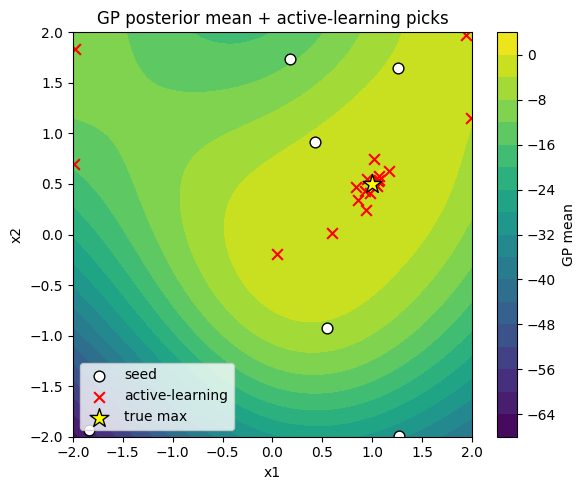

In [8]:
# Visualize: GP posterior mean + sampled points
from discopt.doe.surrogate import coerce_surrogate

s = coerce_surrogate("gp")
s.fit(X, y)

g = np.linspace(-2, 2, 80)
G1, G2 = np.meshgrid(g, g)
Xg = np.column_stack([G1.ravel(), G2.ravel()])
mu, _ = s.predict(Xg)
Mu = mu.reshape(G1.shape)

fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contourf(G1, G2, Mu, levels=20, cmap="viridis")
plt.colorbar(cs, ax=ax, label="GP mean")
ax.scatter(X[:6, 0], X[:6, 1], color="white", edgecolor="k",
           marker="o", s=60, label="seed")
ax.scatter(X[6:, 0], X[6:, 1], color="red", edgecolor="k",
           marker="x", s=60, label="active-learning")
ax.scatter([1.0], [0.5], color="yellow", marker="*", s=200,
           edgecolor="k", label="true max")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.legend(loc="lower left")
ax.set_title("GP posterior mean + active-learning picks")
plt.tight_layout(); plt.show()


## 4. Practical guidance

### Choosing a surrogate

| Surrogate         | When                                                | Tradeoff                                          |
|-------------------|-----------------------------------------------------|---------------------------------------------------|
| `"gp"`            | default; few runs (< 200); smooth response          | scales as $O(n^3)$; needs hyperparameter fit     |
| `"response-surface"` | classical Box-Wilson; want interpretable model   | restricted to degree-2; weak far from sampled X   |
| `GaussianProcessRegressor(kernel=...)` | you want a specific kernel           | same scaling as `"gp"`; you own the kernel        |
| `pycse.sklearn.lpr.LinearLPR()`        | LPR's local linear UQ                | adapter converts interval to σ automatically      |
| Custom `Surrogate` | you have a bespoke Bayesian model                  | full control; you implement `fit` + `predict`     |

### Choosing an acquisition

* `expected_improvement` — start here. Self-tuning balance of
  exploration and exploitation. The default in {cite:t}`Jones1998`.
* `ucb` / `lcb` — same idea, simpler math; tune via
  `acquisition_kwargs={"kappa": ...}`. Larger κ → more exploration.
* `steepest_ascent` — Box-Wilson behavior; ignores uncertainty.
  Pair with `"response-surface"` if you want to reproduce classical
  RSM. Don't pair with a GP — you'd be throwing away the σ.

### Stopping

There is no fixed budget. Common heuristics:

* stop when the incumbent has not improved for $k$ rounds;
* stop when the acquisition score at the best candidate falls
  below a tolerance (low EI means the GP no longer expects
  improvement anywhere);
* stop when you've spent the budget you can afford.

### Limitations of the current implementation

* Inputs must be numeric in the workbook. Encode categorical
  factors as 0/1 indicators upstream.
* Constraints other than the input box bounds are not yet supported.
* The greedy mean-imputation batch construction is fast but
  suboptimal for very large batches; for $\text{batch} > 8$
  consider running rounds with smaller batches more often.

## References

* {cite:t}`Box1951` — classical steepest-ascent / response-surface
  methodology.
* {cite:t}`Jones1998` — Efficient Global Optimization (EGO):
  Kriging surrogate + Expected Improvement.
* {cite:t}`Rasmussen2006` — the standard reference on GP regression.
* {cite:t}`Snoek2012` — modern recipes for batch Bayesian
  optimization in hyperparameter tuning, applicable to physical
  experimentation as well.
